**Verificar GPU y versión de PyTorch**

In [ ]:
# @title
# ==========================================================
# CELDA 1: Verificación del entorno de trabajo
# ==========================================================

import torch

print("Versión de PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Versión de PyTorch: 2.11.0+cu128
CUDA disponible: True
GPU: Tesla T4


**Montar Google Drive**

In [ ]:
# @title
# ==========================================================
# CELDA 2: Conexión con Google Drive
# ==========================================================

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Instalar dependencias**

In [ ]:
# @title
# ==========================================================
# CELDA 3: Instalación de librerías necesarias
# ==========================================================

!pip install -q albumentations
!pip install -q opencv-python

**Importar librerías**

In [ ]:
# @title
# ==========================================================
# CELDA 4: Importación de librerías
# ==========================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import albumentations as A

**Rutas del dataset DRIVE**

In [ ]:
# @title
# ==========================================================
# CELDA 5: Definición de rutas
# ==========================================================

ROOT_DIR = "/content/drive/MyDrive/Colab Notebooks/dataset/DRIVE"

TRAIN_DIR = os.path.join(ROOT_DIR, "training")
TEST_DIR = os.path.join(ROOT_DIR, "test")

print("Ruta principal:")
print(ROOT_DIR)

Ruta principal:
/content/drive/MyDrive/Colab Notebooks/dataset/DRIVE


**Verificar estructura del dataset**

In [ ]:
# @title
# ==========================================================
# CELDA 6: Verificación de carpetas
# ==========================================================

print("Contenido de training:")
print(os.listdir(TRAIN_DIR))

print("\nContenido de test:")
print(os.listdir(TEST_DIR))

Contenido de training:
['1st_manual', 'images', 'mask']

Contenido de test:
['mask', 'images']


**Contar imágenes disponibles**

In [ ]:
# @title
# ==========================================================
# CELDA 7: Conteo de imágenes y máscaras
# ==========================================================

train_images = os.listdir(os.path.join(TRAIN_DIR, "images"))

print("Número de imágenes de entrenamiento:")
print(len(train_images))

Número de imágenes de entrenamiento:
20


**Mostrar nombres de archivos**

In [ ]:
# ==========================================================
# CELDA 8: Inspección de nombres de archivos
# ==========================================================

for archivo in sorted(train_images)[:10]:
    print(archivo)

21_training.tif
22_training.tif
23_training.tif
24_training.tif
25_training.tif
26_training.tif
27_training.tif
28_training.tif
29_training.tif
30_training.tif


**Cargar una imagen de ejemplo**

In [ ]:
# @title
# ==========================================================
# CELDA 9: Lectura de una imagen de ejemplo
# ==========================================================

sample_name = sorted(train_images)[0]

sample_path = os.path.join(
    TRAIN_DIR,
    "images",
    sample_name
)

image = cv2.imread(sample_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Forma:", image.shape)

Forma: (584, 565, 3)


**Visualizar imagen**

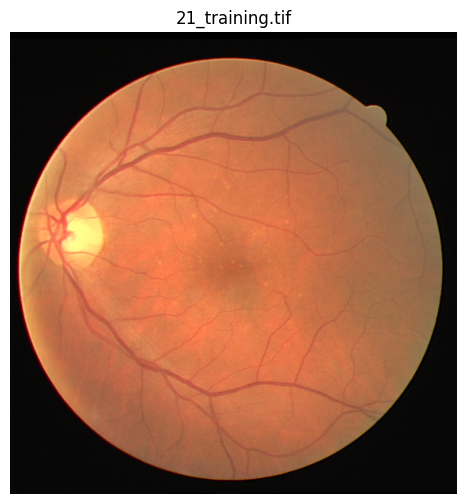

In [ ]:
# @title
# ==========================================================
# CELDA 10: Visualización de imagen
# ==========================================================

plt.figure(figsize=(6,6))

plt.imshow(image)

plt.title(sample_name)
plt.axis("off")

plt.show()

**Explorar las máscaras manuales**

In [ ]:
# @title
# ==========================================================
# CELDA 11: Exploración de máscaras
# ==========================================================

manual_dir = os.path.join(TRAIN_DIR, "1st_manual")

manual_files = sorted(os.listdir(manual_dir))

print("Número de máscaras:", len(manual_files))

for f in manual_files[:5]:
    print(f)

Número de máscaras: 20
21_manual1.gif
22_manual1.gif
23_manual1.gif
24_manual1.gif
25_manual1.gif


**Visualizar una máscara**

Forma máscara: (584, 565)


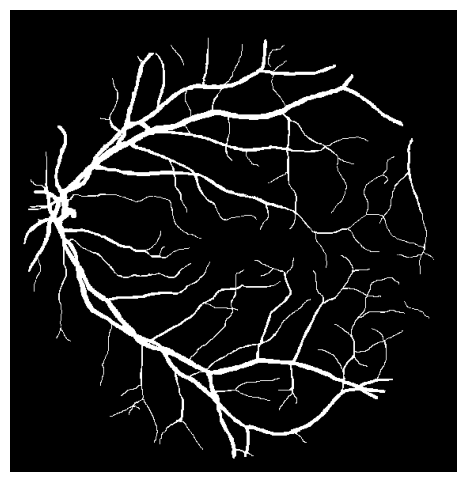

In [ ]:
# @title
# ==========================================================
# CELDA 12: Visualización de una máscara
# ==========================================================

mask_path = os.path.join(
    TRAIN_DIR,
    "1st_manual",
    manual_files[0]
)

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

print("Forma máscara:", mask.shape)

plt.figure(figsize=(6,6))
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()

**Crear transformaciones**

In [ ]:
# @title
# ==========================================================
# CELDA 13: Transformaciones
# ==========================================================

IMG_HEIGHT = 256
IMG_WIDTH = 256

transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH)
])

**Dataset personalizado completo**

In [ ]:
# @title
# ==========================================================
# CELDA 14: Dataset personalizado DRIVE
# ==========================================================

class RetinalDataset(Dataset):

    def __init__(self,
                 image_dir,
                 mask_dir,
                 transform=None):

        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

        self.images = sorted(os.listdir(image_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_name = self.images[idx]

        # Ejemplo:
        # 21_training.tif -> 21_manual1.gif

        image_id = image_name.split("_")[0]

        mask_name = f"{image_id}_manual1.gif"

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        mask_path = os.path.join(
            self.mask_dir,
            mask_name
        )

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )

        if self.transform:

            augmented = self.transform(
                image=image,
                mask=mask
            )

            image = augmented["image"]
            mask = augmented["mask"]

        image = image.astype(np.float32) / 255.0

        mask = (mask > 0).astype(np.float32)

        image = torch.tensor(
            image,
            dtype=torch.float32
        ).permute(2, 0, 1)

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        ).unsqueeze(0)

        return image, mask

**Crear Dataset**

In [ ]:
# @title
# ==========================================================
# CELDA 15: Creación del Dataset
# ==========================================================

train_dataset = RetinalDataset(
    image_dir=os.path.join(TRAIN_DIR, "images"),
    mask_dir=os.path.join(TRAIN_DIR, "1st_manual"),
    transform=transform
)

print("Cantidad de muestras:")
print(len(train_dataset))

Cantidad de muestras:
20


**Verificar dimensiones**

In [ ]:
# @title
# ==========================================================
# CELDA 16: Verificación de dimensiones
# ==========================================================

image, mask = train_dataset[0]

print("Imagen:")
print(image.shape)

print()

print("Máscara:")
print(mask.shape)

Imagen:
torch.Size([3, 256, 256])

Máscara:
torch.Size([1, 256, 256])


**Visualizar imagen y máscara**

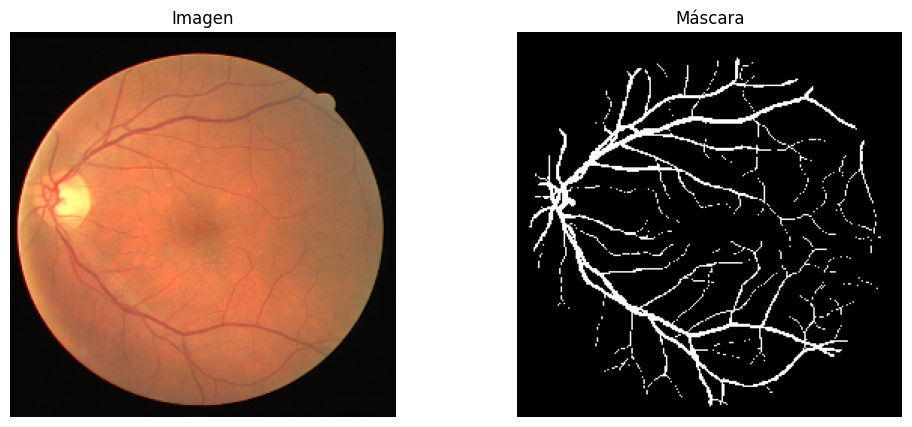

In [ ]:
# @title
# ==========================================================
# CELDA 17: Visualización de muestra
# ==========================================================

image, mask = train_dataset[0]

image_np = image.permute(1,2,0).numpy()

mask_np = mask.squeeze().numpy()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image_np)
plt.title("Imagen")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask_np, cmap="gray")
plt.title("Máscara")
plt.axis("off")

plt.show()

**Crear DataLoader**

In [ ]:
# @title
# ==========================================================
# CELDA 18: DataLoader
# ==========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

print("DataLoader creado correctamente")

DataLoader creado correctamente


**Verificar batch**

In [ ]:
# @title
# ==========================================================
# CELDA 19: Verificación de batches
# ==========================================================

images, masks = next(iter(train_loader))

print("Batch imágenes:")
print(images.shape)

print()

print("Batch máscaras:")
print(masks.shape)

Batch imágenes:
torch.Size([4, 3, 256, 256])

Batch máscaras:
torch.Size([4, 1, 256, 256])


**Bloque Convolucional**

In [ ]:
# @title
# ==========================================================
# CELDA 20: Bloque convolucional
# ==========================================================

class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True)

        )

    def forward(self, x):

        return self.conv(x)

**Bloque Encoder**

In [ ]:
# @title
# ==========================================================
# CELDA 21: Bloque Encoder
# ==========================================================

class Down(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = DoubleConv(
            in_channels,
            out_channels
        )

        self.pool = nn.MaxPool2d(2)

    def forward(self, x):

        skip = self.conv(x)

        x = self.pool(skip)

        return x, skip

**Bloque Decoder**

In [ ]:
# @title
# ==========================================================
# CELDA 22: Bloque Decoder
# ==========================================================

class Up(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            in_channels // 2,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            in_channels,
            out_channels
        )

    def forward(self, x, skip):

        x = self.up(x)

        x = torch.cat(
            [skip, x],
            dim=1
        )

        x = self.conv(x)

        return x

**Implementación completa de U-Net**

In [ ]:
# @title
# ==========================================================
# CELDA 23: U-Net completa
# ==========================================================

class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder

        self.down1 = Down(3, 64)
        self.down2 = Down(64, 128)
        self.down3 = Down(128, 256)
        self.down4 = Down(256, 512)

        # Bottleneck

        self.bottleneck = DoubleConv(
            512,
            1024
        )

        # Decoder

        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)

        # Salida

        self.output = nn.Conv2d(
            64,
            1,
            kernel_size=1
        )

    def forward(self, x):

        x, skip1 = self.down1(x)

        x, skip2 = self.down2(x)

        x, skip3 = self.down3(x)

        x, skip4 = self.down4(x)

        x = self.bottleneck(x)

        x = self.up1(x, skip4)

        x = self.up2(x, skip3)

        x = self.up3(x, skip2)

        x = self.up4(x, skip1)

        x = self.output(x)

        return x

**Crear modelo**

In [ ]:
# @title
# ==========================================================
# CELDA 24: Inicialización del modelo
# ==========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = UNet().to(device)

print(model)

UNet(
  (down1): Down(
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (down2): Down(
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine

**Verificar propagación**

In [ ]:
# @title
# ==========================================================
# CELDA 25: Verificación Forward Pass
# ==========================================================

x = torch.randn(
    1,
    3,
    256,
    256
).to(device)

with torch.no_grad():

    y = model(x)

print("Entrada:", x.shape)
print("Salida :", y.shape)

Entrada: torch.Size([1, 3, 256, 256])
Salida : torch.Size([1, 1, 256, 256])


**Contar parámetros**

In [ ]:
# @title
# ==========================================================
# CELDA 26: Número de parámetros
# ==========================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Parámetros totales:", total_params)
print("Parámetros entrenables:", trainable_params)

Parámetros totales: 31043521
Parámetros entrenables: 31043521


**Función de pérdida**

In [ ]:
# @title
# ==========================================================
# CELDA 27: Función de pérdida
# ==========================================================

criterion = nn.BCEWithLogitsLoss()

print("Loss configurada correctamente")

Loss configurada correctamente


**Optimizador**

In [ ]:
# @title
# ==========================================================
# CELDA 28: Optimizador
# ==========================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Adam configurado")

Adam configurado


**Función de entrenamiento**

In [ ]:
# @title
# ==========================================================
# CELDA 29: Función de entrenamiento
# ==========================================================

def train_one_epoch(model,
                    loader,
                    optimizer,
                    criterion,
                    device):

    model.train()

    epoch_loss = 0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            masks
        )

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)

**Entrenamiento principal**

In [ ]:
# @title
# ==========================================================
# CELDA 30: Entrenamiento
# ==========================================================

NUM_EPOCHS = 20

history = []

for epoch in range(NUM_EPOCHS):

    loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    history.append(loss)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Loss: {loss:.4f}"
    )

Epoch [1/20] Loss: 0.7263
Epoch [2/20] Loss: 0.6263
Epoch [3/20] Loss: 0.5549
Epoch [4/20] Loss: 0.5089
Epoch [5/20] Loss: 0.4742
Epoch [6/20] Loss: 0.4529
Epoch [7/20] Loss: 0.4392
Epoch [8/20] Loss: 0.4276
Epoch [9/20] Loss: 0.4273
Epoch [10/20] Loss: 0.4165
Epoch [11/20] Loss: 0.4118
Epoch [12/20] Loss: 0.4013
Epoch [13/20] Loss: 0.3941
Epoch [14/20] Loss: 0.3883
Epoch [15/20] Loss: 0.3818
Epoch [16/20] Loss: 0.3745
Epoch [17/20] Loss: 0.3698
Epoch [18/20] Loss: 0.3640
Epoch [19/20] Loss: 0.3588
Epoch [20/20] Loss: 0.3546


**Curva de pérdida**

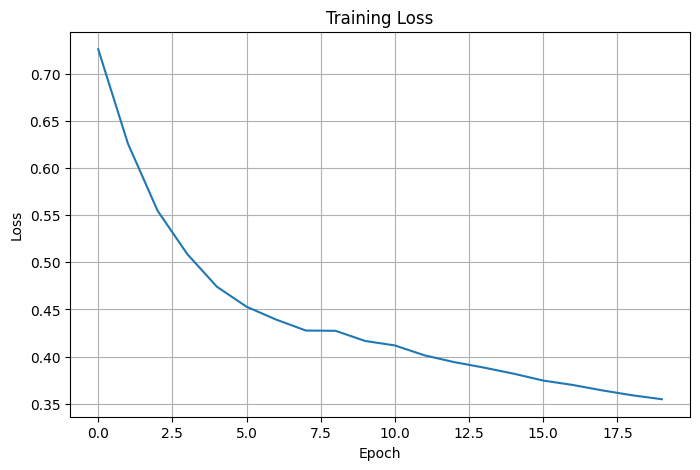

In [ ]:
# @title
# ==========================================================
# CELDA 31: Curva de entrenamiento
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(history)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid()

plt.show()

**Guardar modelo**

In [ ]:
# @title
# ==========================================================
# CELDA 32: Guardar modelo
# ==========================================================

torch.save(
    model.state_dict(),
    "unet_drive_bce.pth"
)

print("Modelo guardado")

Modelo guardado


**Predicción sobre una imagen de entrenamiento**

In [ ]:
# @title
# ==========================================================
# CELDA 33: Predicción de ejemplo
# ==========================================================

model.eval()

image, mask = train_dataset[0]

with torch.no_grad():

    pred = model(
        image.unsqueeze(0).to(device)
    )

    pred = torch.sigmoid(pred)

    pred = pred.squeeze().cpu().numpy()

print(pred.shape)

(256, 256)


**Binarizar predicción**

In [ ]:
# @title
# ==========================================================
# CELDA 34: Binarización
# ==========================================================

binary_pred = (pred > 0.5).astype(np.uint8)

print(
    "Pixeles segmentados:",
    binary_pred.sum()
)

Pixeles segmentados: 4473


**Comparación visual**

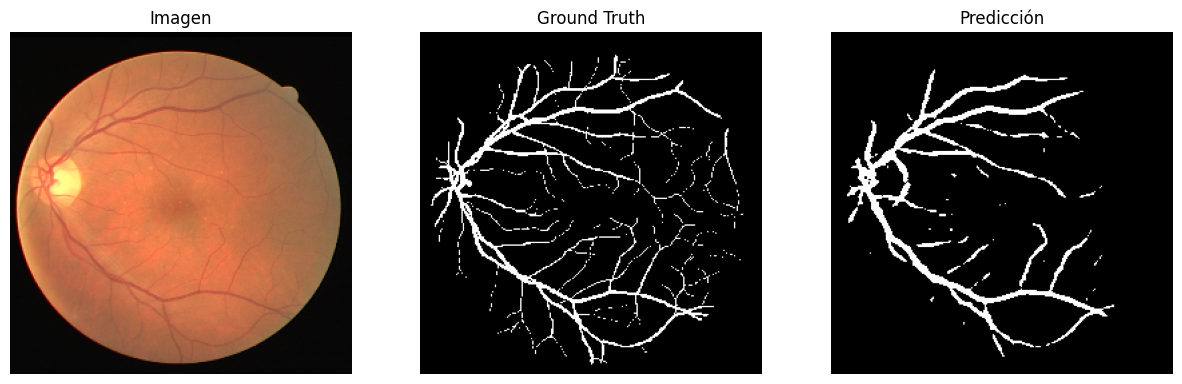

In [ ]:
# @title
# ==========================================================
# CELDA 35: Comparación visual
# ==========================================================

image_np = image.permute(1,2,0).numpy()

mask_np = mask.squeeze().numpy()

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image_np)
plt.title("Imagen")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask_np, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(binary_pred, cmap="gray")
plt.title("Predicción")
plt.axis("off")

plt.show()

**Comparación en varias imágenes**

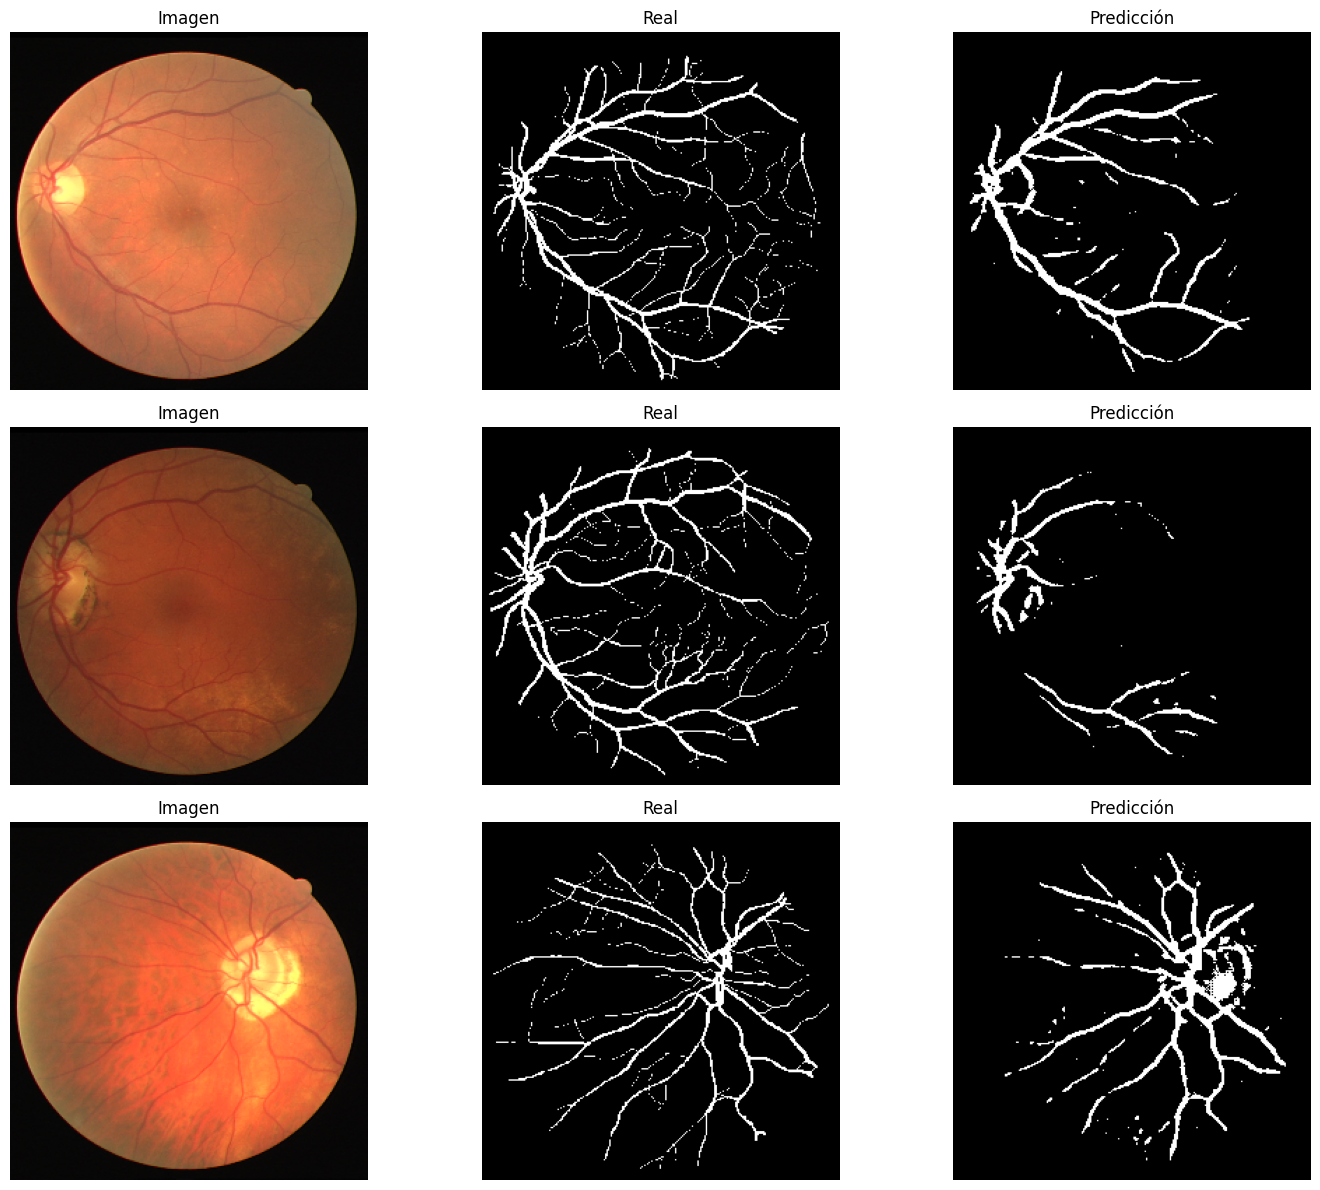

In [ ]:
# @title
# ==========================================================
# CELDA 36: Visualización múltiple
# ==========================================================

model.eval()

indices = [0, 5, 10]

plt.figure(figsize=(15,12))

for i, idx in enumerate(indices):

    image, mask = train_dataset[idx]

    with torch.no_grad():

        pred = model(
            image.unsqueeze(0).to(device)
        )

        pred = torch.sigmoid(pred)

        pred = pred.squeeze().cpu().numpy()

    pred = (pred > 0.5).astype(np.uint8)

    plt.subplot(len(indices),3,3*i+1)
    plt.imshow(image.permute(1,2,0))
    plt.axis("off")
    plt.title("Imagen")

    plt.subplot(len(indices),3,3*i+2)
    plt.imshow(mask.squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Real")

    plt.subplot(len(indices),3,3*i+3)
    plt.imshow(pred, cmap="gray")
    plt.axis("off")
    plt.title("Predicción")

plt.tight_layout()
plt.show()

**Antes de calcular métricas**

In [ ]:
# @title
# ==========================================================
# CELDA 37: Verificar conjunto test
# ==========================================================

test_images_dir = os.path.join(TEST_DIR, "images")
test_mask_dir = os.path.join(TEST_DIR, "mask")

print("Imágenes test:")
print(len(os.listdir(test_images_dir)))

print()

print("Máscaras test:")
print(len(os.listdir(test_mask_dir)))

print()

print("Primeras máscaras:")

for f in sorted(os.listdir(test_mask_dir))[:5]:
    print(f)

Imágenes test:
20

Máscaras test:
20

Primeras máscaras:
01_test_mask.gif
02_test_mask.gif
03_test_mask.gif
04_test_mask.gif
05_test_mask.gif


**Dataset de prueba**

In [ ]:
# @title
# ==========================================================
# CELDA 38: Dataset de prueba DRIVE
# ==========================================================

class DriveTestDataset(Dataset):

    def __init__(self,
                 image_dir,
                 mask_dir,
                 transform=None):

        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

        self.images = sorted(os.listdir(image_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_name = self.images[idx]

        image_id = image_name.split("_")[0]

        mask_name = f"{image_id}_test_mask.gif"

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        mask_path = os.path.join(
            self.mask_dir,
            mask_name
        )

        image = cv2.imread(image_path)
        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        mask = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )

        if self.transform:

            augmented = self.transform(
                image=image,
                mask=mask
            )

            image = augmented["image"]
            mask = augmented["mask"]

        image = image.astype(np.float32) / 255.0

        mask = (mask > 0).astype(np.float32)

        image = torch.tensor(
            image,
            dtype=torch.float32
        ).permute(2,0,1)

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        ).unsqueeze(0)

        return image, mask

**Crear DataLoader de prueba**

In [ ]:
# @title
# ==========================================================
# CELDA 39: DataLoader de prueba
# ==========================================================

test_dataset = DriveTestDataset(
    image_dir=os.path.join(TEST_DIR, "images"),
    mask_dir=os.path.join(TEST_DIR, "mask"),
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)

print("Imágenes de prueba:", len(test_dataset))

Imágenes de prueba: 20


**Instalar métricas**

In [ ]:
# @title
# ==========================================================
# CELDA 40: Métricas
# ==========================================================

from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    confusion_matrix
)

**Evaluación completa**

In [ ]:
# @title
# ==========================================================
# CELDA 41: Evaluación DRIVE-Test
# ==========================================================

model.eval()

all_preds = []
all_probs = []
all_masks = []

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).float()

        all_probs.extend(
            probs.cpu().numpy().flatten()
        )

        all_preds.extend(
            preds.cpu().numpy().flatten()
        )

        all_masks.extend(
            masks.numpy().flatten()
        )

print("Evaluación completada")

Evaluación completada


**Calcular métricas**

In [ ]:
# @title
# ==========================================================
# CELDA 42: Métricas finales
# ==========================================================

tn, fp, fn, tp = confusion_matrix(
    all_masks,
    all_preds
).ravel()

sensitivity = tp / (tp + fn)

specificity = tn / (tn + fp)

f1 = f1_score(
    all_masks,
    all_preds
)

auc = roc_auc_score(
    all_masks,
    all_probs
)

print(f"Sensibilidad : {sensitivity:.4f}")
print(f"Especificidad: {specificity:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"AUC-ROC      : {auc:.4f}")

Sensibilidad : 0.1030
Especificidad: 1.0000
F1 Score     : 0.1867
AUC-ROC      : 0.9589


**Matriz de confusión**

In [ ]:
# @title
# ==========================================================
# CELDA 43: Matriz de confusión
# ==========================================================

print("TP:", tp)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)

TP: 92811
TN: 409325
FP: 0
FN: 808584


**Implementación de Dice Loss**

In [ ]:
# @title
# ==========================================================
# CELDA 44: Dice Loss
# ==========================================================

class DiceLoss(nn.Module):

    def __init__(self, smooth=1):

        super().__init__()

        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.sigmoid(logits)

        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (
            probs * targets
        ).sum()

        dice = (
            2 * intersection + self.smooth
        ) / (
            probs.sum()
            + targets.sum()
            + self.smooth
        )

        return 1 - dice

**Crear nuevo modelo**

In [ ]:
# @title
# ==========================================================
# CELDA 45: Nuevo modelo U-Net
# ==========================================================

model_dice = UNet().to(device)

print("Modelo Dice creado")

Modelo Dice creado


**Configurar entrenamiento Dice**

In [ ]:
# @title
# ==========================================================
# CELDA 46: Configuración Dice
# ==========================================================

criterion_dice = DiceLoss()

optimizer_dice = torch.optim.Adam(
    model_dice.parameters(),
    lr=1e-4
)

print("Dice Loss configurada")

Dice Loss configurada


**Función de entrenamiento genérica**

In [ ]:
# @title
# ==========================================================
# CELDA 47: Entrenamiento genérico
# ==========================================================

def train_model(
    model,
    loader,
    optimizer,
    criterion,
    epochs,
    device
):

    history = []

    for epoch in range(epochs):

        model.train()

        epoch_loss = 0

        for images, masks in loader:

            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                masks
            )

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = (
            epoch_loss /
            len(loader)
        )

        history.append(avg_loss)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {avg_loss:.4f}"
        )

    return history

**Entrenar con Dice**

In [ ]:
# @title
# ==========================================================
# CELDA 48: Entrenamiento Dice
# ==========================================================

history_dice = train_model(
    model_dice,
    train_loader,
    optimizer_dice,
    criterion_dice,
    epochs=20,
    device=device
)

Epoch [1/20] Loss: 0.8227
Epoch [2/20] Loss: 0.7885
Epoch [3/20] Loss: 0.7658
Epoch [4/20] Loss: 0.7488
Epoch [5/20] Loss: 0.7336
Epoch [6/20] Loss: 0.7184
Epoch [7/20] Loss: 0.7101
Epoch [8/20] Loss: 0.7027
Epoch [9/20] Loss: 0.6924
Epoch [10/20] Loss: 0.6857
Epoch [11/20] Loss: 0.6793
Epoch [12/20] Loss: 0.6740
Epoch [13/20] Loss: 0.6684
Epoch [14/20] Loss: 0.6633
Epoch [15/20] Loss: 0.6581
Epoch [16/20] Loss: 0.6524
Epoch [17/20] Loss: 0.6470
Epoch [18/20] Loss: 0.6404
Epoch [19/20] Loss: 0.6349
Epoch [20/20] Loss: 0.6286


**Curva Dice**

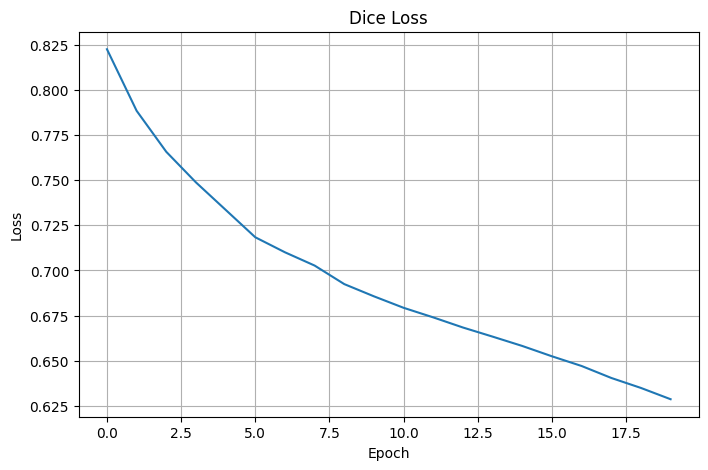

In [ ]:
# @title
# ==========================================================
# CELDA 49: Curva Dice
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(history_dice)

plt.title("Dice Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid()

plt.show()

**Evaluación Dice**

In [ ]:
# @title
# ==========================================================
# CELDA 50: Función de evaluación
# ==========================================================

from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    confusion_matrix
)

def evaluate_model(
    model,
    loader,
    device
):

    model.eval()

    all_preds = []
    all_probs = []
    all_masks = []

    with torch.no_grad():

        for images, masks in loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            preds = (
                probs > 0.5
            ).float()

            all_probs.extend(
                probs.cpu().numpy().flatten()
            )

            all_preds.extend(
                preds.cpu().numpy().flatten()
            )

            all_masks.extend(
                masks.numpy().flatten()
            )

    tn, fp, fn, tp = confusion_matrix(
        all_masks,
        all_preds
    ).ravel()

    sensitivity = tp / (tp + fn)

    specificity = tn / (tn + fp)

    f1 = f1_score(
        all_masks,
        all_preds
    )

    auc = roc_auc_score(
        all_masks,
        all_probs
    )

    return (
        sensitivity,
        specificity,
        f1,
        auc
    )

**Métricas Dice**

In [ ]:
# ==========================================================
# CELDA 51: Resultados Dice
# ==========================================================

sens_dice, spec_dice, f1_dice, auc_dice = evaluate_model(
    model_dice,
    test_loader,
    device
)

print(f"Sensibilidad : {sens_dice:.4f}")
print(f"Especificidad: {spec_dice:.4f}")
print(f"F1 Score     : {f1_dice:.4f}")
print(f"AUC-ROC      : {auc_dice:.4f}")

Sensibilidad : 0.2308
Especificidad: 0.9994
F1 Score     : 0.3750
AUC-ROC      : 0.9106


**BCE + Dice Loss**

In [ ]:
# ==========================================================
# CELDA 52: BCE + Dice Loss
# ==========================================================

class BCEDiceLoss(nn.Module):

    def __init__(self):

        super().__init__()

        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):

        bce_loss = self.bce(
            logits,
            targets
        )

        dice_loss = self.dice(
            logits,
            targets
        )

        return bce_loss + dice_loss

**Nuevo modelo**

In [ ]:
# ==========================================================
# CELDA 53: Nuevo modelo para BCE + Dice
# ==========================================================

model_bce_dice = UNet().to(device)

print("Modelo BCE + Dice creado")

Modelo BCE + Dice creado


**Configuración entrenamiento**

In [ ]:
# ==========================================================
# CELDA 54: Configuración BCE + Dice
# ==========================================================

criterion_bce_dice = BCEDiceLoss()

optimizer_bce_dice = torch.optim.Adam(
    model_bce_dice.parameters(),
    lr=1e-4
)

print("BCE + Dice configurada")

BCE + Dice configurada


**Entrenamiento**

In [ ]:
# ==========================================================
# CELDA 55: Entrenamiento BCE + Dice
# ==========================================================

history_bce_dice = train_model(
    model_bce_dice,
    train_loader,
    optimizer_bce_dice,
    criterion_bce_dice,
    epochs=20,
    device=device
)

Epoch [1/20] Loss: 1.5043
Epoch [2/20] Loss: 1.4104
Epoch [3/20] Loss: 1.3404
Epoch [4/20] Loss: 1.2782
Epoch [5/20] Loss: 1.2222
Epoch [6/20] Loss: 1.1786
Epoch [7/20] Loss: 1.1403
Epoch [8/20] Loss: 1.1186
Epoch [9/20] Loss: 1.0990
Epoch [10/20] Loss: 1.0808
Epoch [11/20] Loss: 1.0642
Epoch [12/20] Loss: 1.0473
Epoch [13/20] Loss: 1.0347
Epoch [14/20] Loss: 1.0254
Epoch [15/20] Loss: 1.0149
Epoch [16/20] Loss: 1.0046
Epoch [17/20] Loss: 0.9994
Epoch [18/20] Loss: 0.9922
Epoch [19/20] Loss: 0.9879
Epoch [20/20] Loss: 0.9812


**Curva de entrenamiento**

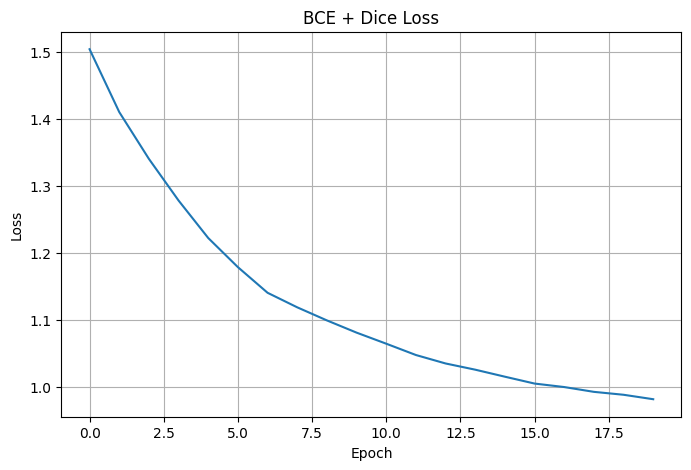

In [ ]:
# ==========================================================
# CELDA 56: Curva BCE + Dice
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(history_bce_dice)

plt.title("BCE + Dice Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid()

plt.show()

**Evaluación BCE + Dice**

In [ ]:
# ==========================================================
# CELDA 57: Evaluación BCE + Dice
# ==========================================================

sens_bd, spec_bd, f1_bd, auc_bd = evaluate_model(
    model_bce_dice,
    test_loader,
    device
)

print(f"Sensibilidad : {sens_bd:.4f}")
print(f"Especificidad: {spec_bd:.4f}")
print(f"F1 Score     : {f1_bd:.4f}")
print(f"AUC-ROC      : {auc_bd:.4f}")

Sensibilidad : 0.3558
Especificidad: 0.9599
F1 Score     : 0.5179
AUC-ROC      : 0.9257


**Tabla comparativa final**

In [ ]:
# ==========================================================
# CELDA 58: Comparación de funciones de pérdida
# ==========================================================

print("------------------------------------------------")
print("              ESTUDIO DE ABLACIÓN")
print("------------------------------------------------")

print(f"BCE")
print(f" Sensibilidad : {0.1030:.4f}")
print(f" Especificidad: {1.0000:.4f}")
print(f" F1 Score     : {0.1867:.4f}")
print(f" AUC-ROC      : {0.9589:.4f}")

print()

print(f"Dice")
print(f" Sensibilidad : {sens_dice:.4f}")
print(f" Especificidad: {spec_dice:.4f}")
print(f" F1 Score     : {f1_dice:.4f}")
print(f" AUC-ROC      : {auc_dice:.4f}")

print()

print(f"BCE + Dice")
print(f" Sensibilidad : {sens_bd:.4f}")
print(f" Especificidad: {spec_bd:.4f}")
print(f" F1 Score     : {f1_bd:.4f}")
print(f" AUC-ROC      : {auc_bd:.4f}")

------------------------------------------------
              ESTUDIO DE ABLACIÓN
------------------------------------------------
BCE
 Sensibilidad : 0.1030
 Especificidad: 1.0000
 F1 Score     : 0.1867
 AUC-ROC      : 0.9589

Dice
 Sensibilidad : 0.2308
 Especificidad: 0.9994
 F1 Score     : 0.3750
 AUC-ROC      : 0.9106

BCE + Dice
 Sensibilidad : 0.3558
 Especificidad: 0.9599
 F1 Score     : 0.5179
 AUC-ROC      : 0.9257
